In [9]:
import os
import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import librosa.display
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt
import sys

sys.path.append('..')
from config import DATA_PATH
from pathlib import Path

np.random.seed(0)

TRAIN_PATH = Path(DATA_PATH) / "train"
TEST_PATH = Path(DATA_PATH) / "test"

In [12]:
splits = {"train": TRAIN_PATH, "test": TEST_PATH}
file_records = []

for split_name, split_path in splits.items():
    wavs = list(split_path.glob("*.WAV"))
    for wav_path in wavs:
        file_records.append({
            "filename": wav_path.name,
            "split": split_name,
            "full_path": wav_path,
        })

file_df = pd.DataFrame(file_records)

print(file_df["split"].value_counts())
print(f"Total .WAV files: {len(file_df)}")

split
train    20265
test      2251
Name: count, dtype: int64
Total .WAV files: 22516


In [ ]:
n_sample = 200
sample_df = file_df.sample(n=min(n_sample, len(file_df)), random_state=0)

info_rows = []
for _, row in sample_df.iterrows():
    info = sf.info(row["full_path"])
    info_rows.append({
        "filename": row["filename"],
        "split": row["split"],
        "samplerate": info.samplerate,
        "duration_s": info.duration,
        "channels": info.channels,
    })

info_df = pd.DataFrame(info_rows)
print("Unique sample rates found (Hz):", info_df["samplerate"].unique())
print("Unique channel counts found:", info_df["channels"].unique())
print(info_df.groupby("split")["duration_s"].describe())

Unique sample rates found: [250000]
Unique channel counts found: [1]
       count      mean       std       min       25%       50%       75%  \
split                                                                      
test    21.0  0.054480  0.032573  0.017604  0.033604  0.044804  0.064004   
train  179.0  0.060974  0.033029  0.009604  0.036804  0.051204  0.076804   

            max  
split            
test   0.147204  
train  0.172804  


Loaded DBA_9858_888.WAV (train): sr=250000, duration=0.0432s, max_amplitude=0.0951


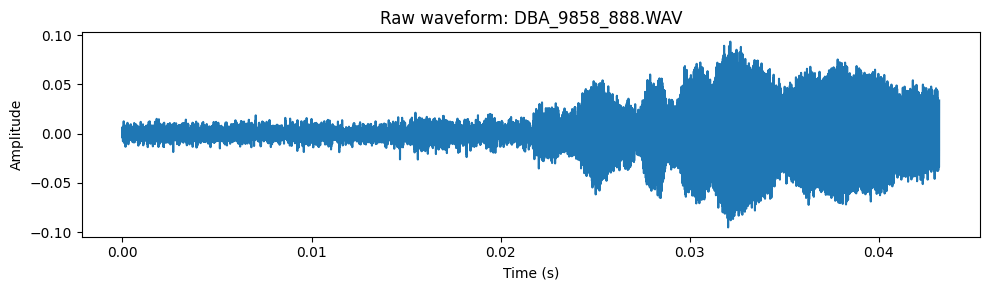

In [ ]:
def load_audio(wav_path, target_sr=None):
    """Load a wav file as mono float32. can  resample to target_sr"""
    audio, sr = sf.read(wav_path)
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    if target_sr is not None and sr != target_sr:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)
        sr = target_sr
    return audio.astype(np.float32), sr

test_row = file_df.iloc[0]
audio, sr = load_audio(test_row["full_path"])

print(f"Loaded {test_row['filename']} ({test_row['split']}): sr={sr}, "
      f"duration={len(audio)/sr:.4f}s, max_amplitude={np.abs(audio).max():.4f}")

plt.figure(figsize=(10, 3))
plt.plot(np.linspace(0, len(audio)/sr, len(audio)), audio)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"Raw waveform: {test_row['filename']}")
plt.tight_layout()
plt.show()
